<h1 style="text-align:center;">Individual Planning Project</h1>

**Student Name:** Mudra Patel  
**Student Number:** 48101778  
**Dataset:** *players.csv* and *sessions.csv*

---
# 1. Data Description:

This project uses data from a Minecraft research server run by a UBC research group. There are two related datasets:

- **players.csv:** Each row represents one player and contains information about their gameplay patterns, demographics, and whether they subscribed to the game newsletter.  
- **sessions.csv:** Each row represents a single play session, with details such as session duration, time started, and number of actions.

<br>
<br>

**Dataset 1: players.csv**

- **Rows (observations):** 196  
- **Columns (variables):** 7  
- **Variables:**

| Variable Name | Type | Description |
|----------------|------|-------------|
| experience | Character | The player’s level of gaming experience (e.g., beginner, intermediate, expert). |
| hashedEmail | Character | A unique encrypted identifier for each player. Used to link with the sessions dataset. |
| name | Character | Player’s in-game or display name. |
| gender | Character | Player’s reported gender. |
| played_hours | Double | Total hours played across all sessions. |
| Age | Double | Player’s age in years. |
| subscribe | Logical (TRUE/FALSE) | Whether the player subscribed to the newsletter (this will be my target variable for the predictive question). |

**Summary:**  
This file gives demographic and performance information about each player.  
It helps identify how player characteristics (like age, gender, and subscription) might relate to their engagement or performance.

<br>
<br>

**Dataset 2: sessions.csv**

- **Rows (observations):** 1,535  
- **Columns (variables):** 5  
- **Variables:**

| Variable Name | Type | Description |
|----------------|------|-------------|
| hashedEmail | Character | Unique encrypted player ID (same as in players.csv for merging). |
| start_time | Character | Start time of a gaming session (recorded as text). |
| end_time | Character | End time of a gaming session (recorded as text). |
| original_start_time | Double | Start time in timestamp form. |
| original_end_time | Double | End time in timestamp form. |

**Summary:**  
This dataset records individual game sessions for each player.  
It can be linked to the players dataset using `hashedEmail`.  
It will allow me to measure overall engagement (like total time played or average session duration) for each player.

<br>
<br>

**Potential Data Issues:**

- Missing or incomplete gender or age data (common in self-reported demographics).  
- Some players might appear in `players.csv` but have no sessions in `sessions.csv`.  
- Time variables may need conversion from text/timestamp to actual time duration.  
- The logical `subscribe` variable might be unbalanced (e.g., far more FALSE than TRUE).  
- There may be duplicate `hashedEmail` values in the sessions data (since one player can have multiple sessions).  
- Inconsistent categories (e.g., “yes” vs “Yes”) and outliers like extremely long playtimes.


# 2. Questions:

**Broad Question:**  
What player characteristics and behaviours are most predictive of subscribing to the newsletter,  
and how do these features differ between types of players?  

<br>

**Specific Question:**  
Can player characteristics like total playtime, average session duration, and number of sessions  
predict whether a player subscribes to the game newsletter?  

<br>

**Why This Question Matters:**  
Predicting who is more likely to subscribe helps researchers plan communication and allocate resources more effectively.  
The player data already includes both engagement and subscription variables, making it directly relevant to this analysis.


# 3. Exploratory Data Analysis and Visualization:
**Demonstrate that the dataset can be loaded into R:**

In [75]:
# Load required libraries
library(readr)
library(dplyr)
library(ggplot2)
library(tidyr)

In [76]:
# Read in the datasets
players <- read_csv("players.csv")
sessions <- read_csv("sessions.csv")

# Check first few rows
players |> head()
sessions |> head()

Rows: 196 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): experience, hashedEmail, name, gender
dbl (2): played_hours, Age
lgl (1): subscribe

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 1535 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): hashedEmail, start_time, end_time
dbl (2): original_start_time, original_end_time

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


experience,subscribe,hashedEmail,played_hours,name,gender,Age
<chr>,<lgl>,<chr>,<dbl>,<chr>,<chr>,<dbl>
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9
Veteran,TRUE,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Christian,Male,17
Veteran,FALSE,b674dd7ee0d24096d1c019615ce4d12b20fcbff12d79d3c5a9d2118eb7ccbb28,0.0,Blake,Male,17
Amateur,TRUE,23fe711e0e3b77f1da7aa221ab1192afe21648d47d2b4fa7a5a659ff443a0eb5,0.7,Flora,Female,21
Regular,TRUE,7dc01f10bf20671ecfccdac23812b1b415acd42c2147cb0af4d48fcce2420f3e,0.1,Kylie,Male,21
Amateur,TRUE,f58aad5996a435f16b0284a3b267f973f9af99e7a89bee0430055a44fa92f977,0.0,Adrian,Female,17


hashedEmail,start_time,end_time,original_start_time,original_end_time
<chr>,<chr>,<chr>,<dbl>,<dbl>
bfce39c89d6549f2bb94d8064d3ce69dc3d7e72b38f431d8aa0c4bf95ccee6bf,30/06/2024 18:12,30/06/2024 18:24,1.71977e+12,1.71977e+12
36d9cbb4c6bc0c1a6911436d2da0d09ec625e43e6552f575d4acc9cf487c4686,17/06/2024 23:33,17/06/2024 23:46,1.71867e+12,1.71867e+12
f8f5477f5a2e53616ae37421b1c660b971192bd8ff77e3398304c7ae42581fdc,25/07/2024 17:34,25/07/2024 17:57,1.72193e+12,1.72193e+12
bfce39c89d6549f2bb94d8064d3ce69dc3d7e72b38f431d8aa0c4bf95ccee6bf,25/07/2024 03:22,25/07/2024 03:58,1.72188e+12,1.72188e+12
36d9cbb4c6bc0c1a6911436d2da0d09ec625e43e6552f575d4acc9cf487c4686,25/05/2024 16:01,25/05/2024 16:12,1.71665e+12,1.71665e+12
bfce39c89d6549f2bb94d8064d3ce69dc3d7e72b38f431d8aa0c4bf95ccee6bf,23/06/2024 15:08,23/06/2024 17:10,1.71916e+12,1.71916e+12


**Do the minimum necessary wrangling to turn your data into a tidy format:**

In [61]:
# Convert logical subscribe to factor
players <- players |> 
  mutate(subscribe = as.factor(subscribe))

# Check for missing values
players |> summarise_all(~ sum(is.na(.)))

experience,subscribe,hashedEmail,played_hours,name,gender,Age
<int>,<int>,<int>,<int>,<int>,<int>,<int>
0,0,0,0,0,0,2


**Compute the mean value for each quantitative variable in the players.csv data set:**

In [62]:
# Compute mean values (rounded to 2 decimals)
mean_table <- players |>
  summarise(across(where(is.numeric), ~ round(mean(.x, na.rm = TRUE), 2)))

mean_table

played_hours,Age
<dbl>,<dbl>
5.85,21.14


**Make a few exploratory visualizations of the data to help understand it:**

Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_bin()`).”


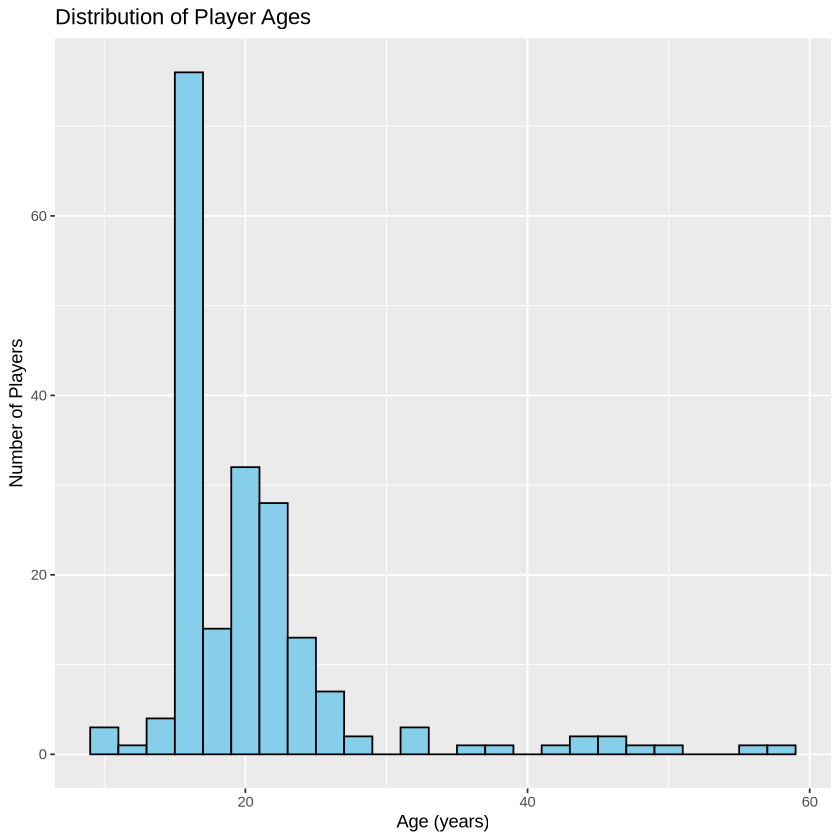

In [63]:
players |>
  ggplot(aes(x = Age)) +
  geom_histogram(binwidth = 2, fill = "skyblue", color = "black") +
  labs(title = "Distribution of Player Ages",
       x = "Age (years)",
       y = "Number of Players")

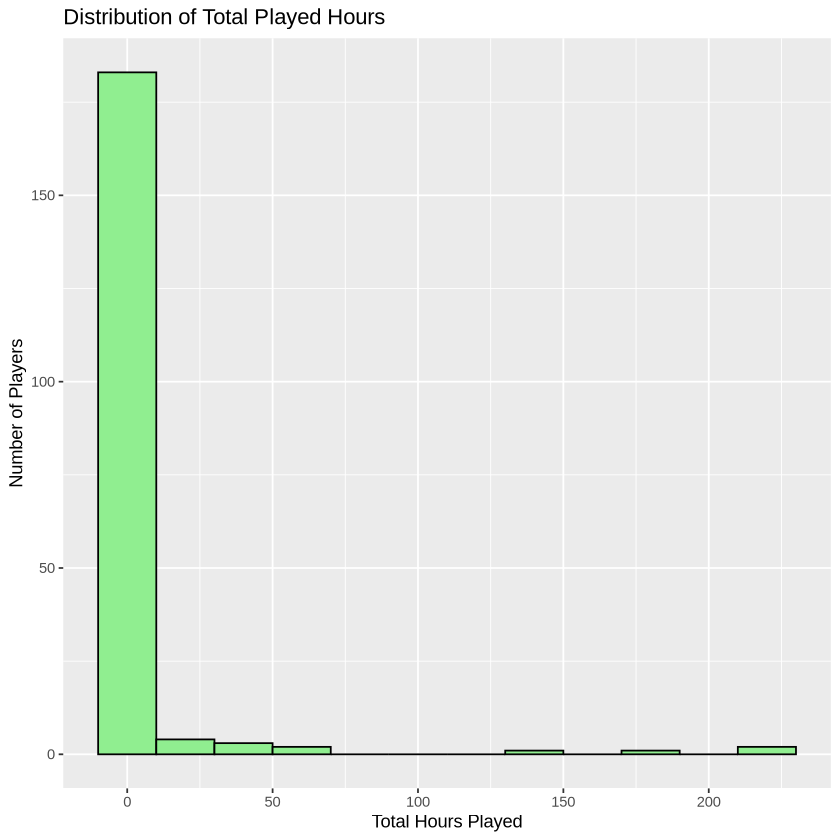

In [64]:
players |>
  ggplot(aes(x = played_hours)) +
  geom_histogram(binwidth = 20, fill = "lightgreen", color = "black") +
  labs(title = "Distribution of Total Played Hours",
       x = "Total Hours Played",
       y = "Number of Players")

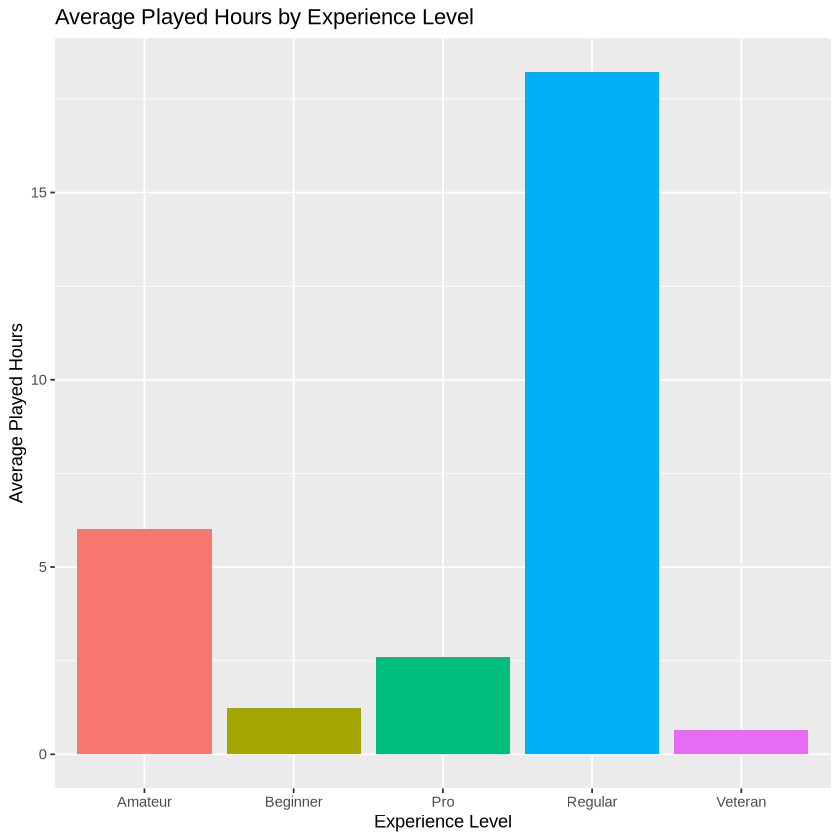

In [65]:
players |>
  group_by(experience) |>
  summarise(mean_hours = mean(played_hours, na.rm = TRUE)) |>
  ggplot(aes(x = experience, y = mean_hours, fill = experience)) +
  geom_col() +
  labs(title = "Average Played Hours by Experience Level",
       x = "Experience Level",
       y = "Average Played Hours") +
  theme(legend.position = "none")

`geom_smooth()` using formula = 'y ~ x'


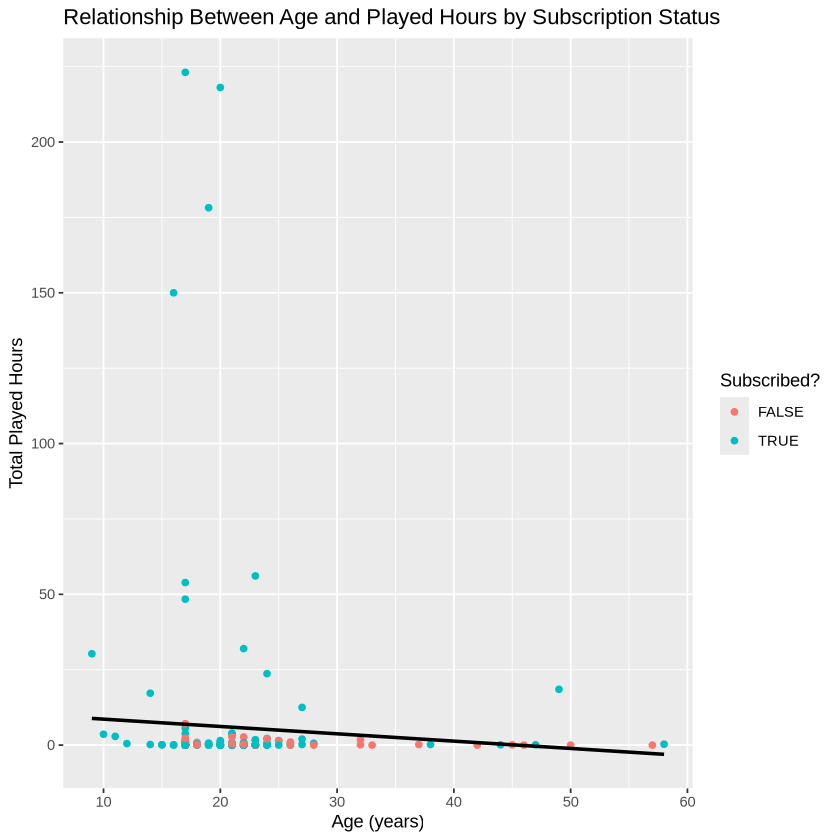

In [66]:
players_clean <- players |> drop_na(Age, played_hours)

players_clean |>
  ggplot(aes(x = Age, y = played_hours, color = subscribe)) +
  geom_point() +
  geom_smooth(method = "lm", se = FALSE, color = "black") +
  labs(title = "Relationship Between Age and Played Hours by Subscription Status",
       x = "Age (years)",
       y = "Total Played Hours",
       color = "Subscribed?")

**Exploratory Data Analysis Insights:**

**1- Age Distribution:**

The age histogram shows that most players are between 18 and 35, indicating a primarily young adult player base, which is typical for gaming populations.

**2- Played Hours Distribution:**

Total played hours are right-skewed. Most players have fewer than 200 hours, while a small group plays 400–500+ hours, showing a minority of highly active players.

**3- Experience vs. Playtime:**

Average played hours increase with experience level. More experienced players tend to spend more time playing, which matches expectations.

**4- Age vs. Played Hours (by Subscription):**

There is no strong linear relationship between age and played hours. However, subscribed players generally show higher playtime than non-subscribers, especially in the younger to mid-age groups.

# 4. Methods and Plan

**Proposed Method - Logistic Regression:**

To predict whether a player subscribes to the newsletter, I will use **logistic regression**. This method is appropriate because the outcome (`subscribe`) is binary, and it allows us to estimate how player characteristics affect subscription likelihood.

**Why It’s Appropriate:**

Logistic regression is interpretable, works well with binary outcomes, and helps identify which factors most influence subscription.

**Assumptions:**

- Binary outcome variable  
- Independent observations  
- Linear relationship between predictors and log-odds   

**Limitations:**

It assumes linear relationships and may not capture complex or non-linear patterns. If needed, more flexible models (like random forests) can be explored later.

**Data Processing and Splitting:**

Data will be cleaned, categorical variables encoded, and numerical features standardized. I will split the data into 70% training and 30% testing sets, using 5-fold cross-validation for model evaluation.

**Evaluation:**

Model performance will be compared using accuracy, precision, recall, and F1-score.

# 5. GitHub Repository

GitHub Repository Link: https://github.com/Mudra5678/Mudra-Patel_Individual-Planning-Project.git